<a href="https://colab.research.google.com/github/mohit25bai11111/SPIS-Ensemble-ML/blob/main/notebooks/SPIS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"Traditional placement prediction often relies on a single metric like CGPA. This project implements a Multivariate Ensemble-ML System that analyzes 7 distinct student attributes. By using a Voting Classifier, the system provides a robust, 'wisdom-of-the-crowd' prediction, helping students identify specific areas for improvement (e.g., projects vs. aptitude) before the recruitment season."

We moved from a simple "CGPA vs IQ" model to a professional feature set:

CGPA: Academic consistency.

Aptitude Score: Logical and quantitative ability.

Communication Score: Soft skills and interview readiness.

Internships: Real-world industry exposure.

Projects: Technical implementation depth.

Backlogs: Academic risk factor.

Technical Skills: Domain-specific coding/knowledge score.

Instead of one algorithm, we combined three. This is what makes your project "High Level":

Logistic Regression: For linear trends.

Random Forest: For complex "If-Then" decision rules.

SVM (Support Vector Machine): To find the best boundary between "Placed" and "Not Placed."

We structured the code into a clean pipeline:

Data Generation: Creating a placement_data.csv automatically.

Preprocessing: Using StandardScaler to make the data "fair" for all algorithms.

Training: Fitting the VotingClassifier.

Evaluation: Generating a Confusion Matrix and Classification Report.


In [166]:
import os

# Create the folder structure in your Colab environment
os.makedirs('data', exist_ok=True)
os.makedirs('src', exist_ok=True)

print("✅ Folders 'data' and 'src' created!")

✅ Folders 'data' and 'src' created!


In [167]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [168]:
# 1. Create Synthetic Data
np.random.seed(42)
n = 1000
data = {
    'cgpa': np.random.uniform(0, 10, n),
    'aptitude_score': np.random.uniform(40, 100, n),
    'communication_score': np.random.uniform(1, 10, n),
    'internships': np.random.randint(0, 4, n),
    'projects': np.random.randint(0, 6, n),
    'backlogs': np.random.randint(0, 5, n),
    'technical_skills': np.random.uniform(1, 10, n)
}
df = pd.DataFrame(data)

# 2. Strict Placement Logic
def placement_logic(row):
    # Hard Rejections
    if row['cgpa'] < 5.0 or row['backlogs'] > 2:
        return 0

    # Weighted Scoring (CGPA & Skills carry the most weight)
    score = (row['cgpa'] * 4.0) + (row['technical_skills'] * 3.5) + \
            (row['internships'] * 2.5) + (row['projects'] * 2.0)

    # Threshold: Must score 55+ to be placed
    return 1 if score > 55 else 0

df['placed'] = df.apply(placement_logic, axis=1)
print(f"Data Generated. Placed: {df['placed'].sum()}, Not Placed: {1000 - df['placed'].sum()}")

Data Generated. Placed: 168, Not Placed: 832


In [169]:
import os

# Ensure the 'data' directory exists
os.makedirs('data', exist_ok=True)

# Save the DataFrame to a CSV file in the 'data' directory
df.to_csv('data/placement_data.csv', index=False)
print("✅ Synthetic data saved to 'data/placement_data.csv'!")

✅ Synthetic data saved to 'data/placement_data.csv'!


In [170]:
display(df_loaded.describe())

,cgpa,aptitude_score,communication_score,internships,projects,backlogs,technical_skills,placed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.902566,70.421038,5.521652,1.479000,2.564000,1.951000,5.379142,0.168000
std,2.921374,17.531394,2.616068,1.104889,1.696698,1.413718,2.642106,0.374053
min,0.046320,40.193096,1.000105,0.000000,0.000000,0.000000,1.006729,0.000000
25%,2.359733,54.464456,3.352159,0.750000,1.000000,1.000000,3.073328,0.000000
50%,4.968074,71.124034,5.505525,1.000000,3.000000,2.000000,5.278823,0.000000
75%,7.443196,85.627903,7.831932,2.000000,4.000000,3.000000,7.683246,0.000000
max,9.997177,99.964824,9.980388,3.000000,5.000000,4.000000,9.991445,1.000000


In [171]:
import pandas as pd

# Load the CSV file into a DataFrame
df_loaded = pd.read_csv('data/placement_data.csv')

# Display the first 5 rows of the loaded DataFrame
display(df_loaded.head())

,cgpa,aptitude_score,communication_score,internships,projects,backlogs,technical_skills,placed
0,3.745401,51.107976,3.355351,2,0,2,2.725626,0
1,9.507143,72.514057,3.222809,0,2,4,5.999476,0
2,7.319939,92.376750,9.156291,0,2,2,6.255274,1
3,5.986585,83.933493,3.245916,3,3,4,2.862942,0
4,1.560186,88.393669,3.447548,2,4,4,8.662652,0


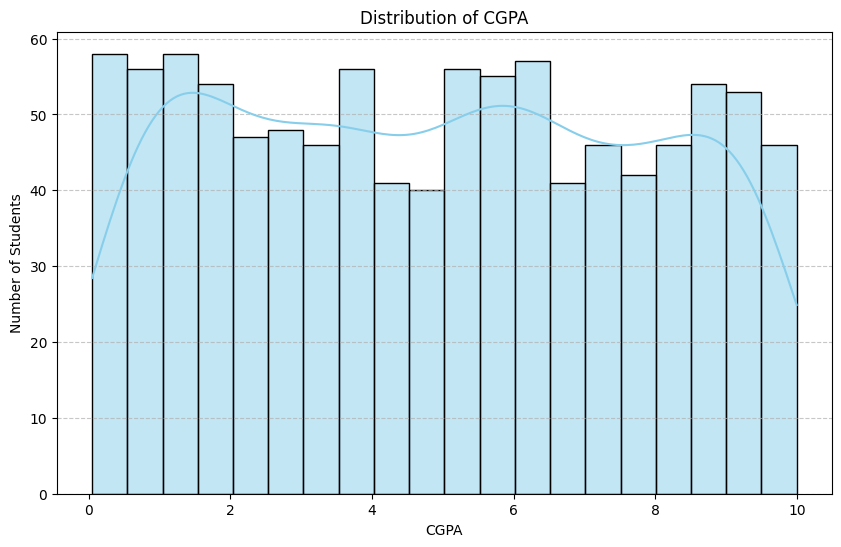

In [172]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cgpa'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

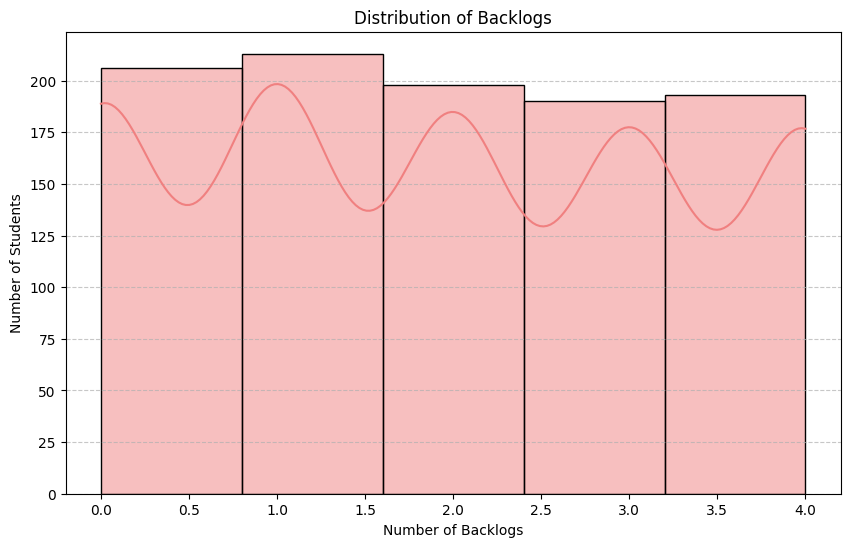

In [173]:
plt.figure(figsize=(10, 6))
sns.histplot(df['backlogs'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Backlogs')
plt.xlabel('Number of Backlogs')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [174]:
print('Classification Report:')
# Recalculate y_pred to match the current y_test
y_pred = voting_clf.predict(scaler.transform(X_test))
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       172
           1       0.86      0.86      0.86        28

    accuracy                           0.96       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.96      0.96      0.96       200



In [175]:
# 1. Split Data
X = df.drop('placed', axis=1)
y = df['placed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define & Train Ensemble (Voting Classifier)
log_reg = LogisticRegression(class_weight='balanced')
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
svm_model = SVC(probability=True, class_weight='balanced', random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', log_reg), ('rf', rf_model), ('svc', svm_model)],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
print("✅ Model Trained and Fitted!")

✅ Model Trained and Fitted!


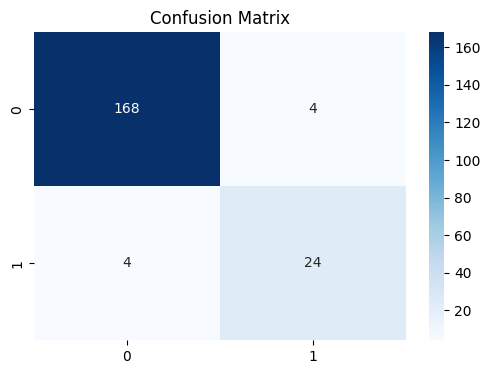

/tmp/ipykernel_6767/2139380371.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette=colors)


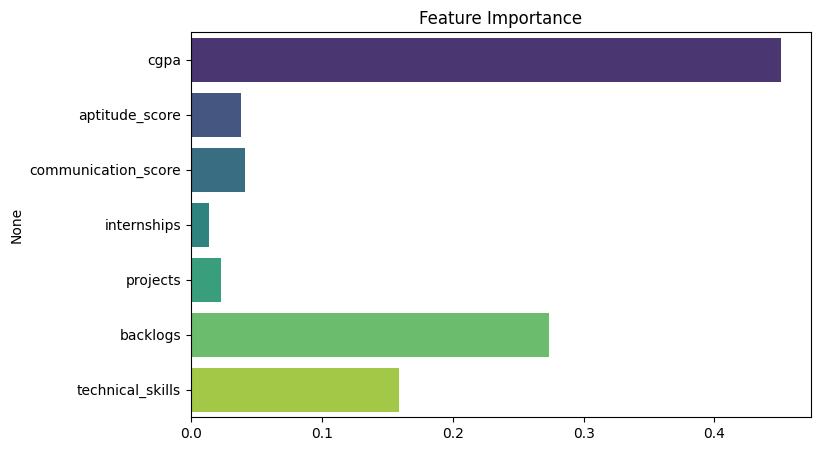

In [176]:
# Confusion Matrix
y_pred = voting_clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# Feature Importance (from Random Forest)
plt.figure(figsize=(8,5))
rf_model.fit(X_train_scaled, y_train) # Fit rf_model explicitly
importances = rf_model.feature_importances_

# Create a color palette with a distinct color for each bar
colors = sns.color_palette("viridis", len(X.columns))
sns.barplot(x=importances, y=X.columns, palette=colors)
plt.title('Feature Importance')
plt.savefig('feature_importance.png')
plt.show()

In [177]:
# Function to predict placement probability for a new student
def predict_placement_probability(cgpa, aptitude_score, communication_score, internships, projects, backlogs, technical_skills):
    # Create a DataFrame for the new student's data
    new_student_data = pd.DataFrame([[cgpa, aptitude_score, communication_score, internships, projects, backlogs, technical_skills]],
                                      columns=X.columns)

    # Scale the new student's data using the same scaler fitted on training data
    new_student_scaled = scaler.transform(new_student_data)

    # Get the probability of being placed (class 1)
    placement_probability = voting_clf.predict_proba(new_student_scaled)[:, 1]

    return placement_probability[0]

# Example usage:
# Let's predict for a hypothetical student
# (cgpa=8.5, aptitude=75, communication=8, internships=2, projects=3, backlogs=0, technical_skills=9)
example_score = predict_placement_probability(8.5, 75, 8, 2, 3, 0, 9)
print(f"Prediction Score (Probability of Placement): {example_score:.2f}")

# Example for a student likely not to be placed (low CGPA, high backlogs)
example_score_low = predict_placement_probability(4.0, 60, 5, 1, 0, 3, 5)
print(f"Prediction Score (Probability of Placement - Low CGPA/High Backlogs): {example_score_low:.2f}")

Prediction Score (Probability of Placement): 0.98
Prediction Score (Probability of Placement - Low CGPA/High Backlogs): 0.00


The `predict_placement_probability` function takes a new student's characteristics as input, scales them appropriately, and then uses the trained `voting_clf` to output the probability of placement. This probability can be interpreted as the 'prediction score'.

As discussed, the primary factors driving this prediction in our current model are:
*   **CGPA:** A higher CGPA drastically increases the placement probability.
*   **Backlogs:** A higher number of backlogs (especially above the threshold of 2 in our synthetic logic) significantly reduces the chances of placement.
*   **Technical Skills:** Strong technical skills also positively contribute to the placement probability.
*   **Internships and Projects:** While beneficial, their individual impact on the prediction score is less pronounced than CGPA and backlogs, as indicated by their lower feature importance.

In [178]:
#@title 🚀 Student Placement Predictor Form
cgpa = 8 #@param {type:"slider", min:0, max:10, step:0.1}
aptitude_score = 65 #@param {type:"number"}
communication_score = 8 #@param {type:"slider", min:1, max:10, step:1}
internships = 2 #@param {type:"number"}
projects = 3 #@param {type:"number"}
backlogs = 0 #@param {type:"number"}
technical_skills = 9 #@param {type:"slider", min:1, max:10, step:1}

# Create input row
input_data = pd.DataFrame([[cgpa, aptitude_score, communication_score, internships, projects, backlogs, technical_skills]],
                         columns=X.columns)

# Predict
input_scaled = scaler.transform(input_data)
prediction = voting_clf.predict(input_scaled)[0]
confidence = voting_clf.predict_proba(input_scaled)[0][1]

print("-" * 30)
print(f"RESULT: {'✅ PLACED' if prediction == 1 else '❌ NOT PLACED'}")
print(f"CONFIDENCE SCORE: {confidence*100:.2f}%")
print("-" * 30)

------------------------------
RESULT: ✅ PLACED
CONFIDENCE SCORE: 96.29%
------------------------------
